#### **Library importation**

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn import tree
from xgboost import plot_tree
import xgboost as xgb

# Surrogate models

In [240]:
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target
print("Dataset shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Dataset shape: (20640, 8)


### **Model black box training**

In [241]:
model_bbox = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_bbox.fit(X_train, y_train)

y_pred_test = model_bbox.predict(X_test)
r2_bbox = r2_score(y_test, y_pred_test)
mse_bbox = mean_squared_error(y_test, y_pred_test)
rmse_bbox = np.sqrt(mse_bbox)

print(f"XGBoost R² (test): {r2_bbox:.3f}")
print(f"XGBoost RMSE (test): {rmse_bbox:.3f}")


XGBoost R² (test): 0.843
XGBoost RMSE (test): 0.453


### **Surrogate model (Decision Tree)**

Now the target for our surrogate model is the prediction on X_train provide by Black Box model

In [99]:
target_surrogate = model_bbox.predict(X_train)

In [100]:
surrogate_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
surrogate_tree.fit(X_train, target_surrogate)
pred_tree = surrogate_tree.predict(X_train)

r2_tree = r2_score(target_surrogate, pred_tree)
mse_tree = mean_squared_error(target_surrogate, pred_tree)
rmse_tree = np.sqrt(mse_tree)


In [101]:
print(f"Fidelity surrogate TREE:   R²={r2_tree:.3f}, RMSE={rmse_tree:.3f}")


Fidelity surrogate TREE:   R²=0.639, RMSE=0.643


MedInc: 0.853
HouseAge: 0.000
AveRooms: 0.028
AveBedrms: 0.000
Population: 0.000
AveOccup: 0.120
Latitude: 0.000
Longitude: 0.000


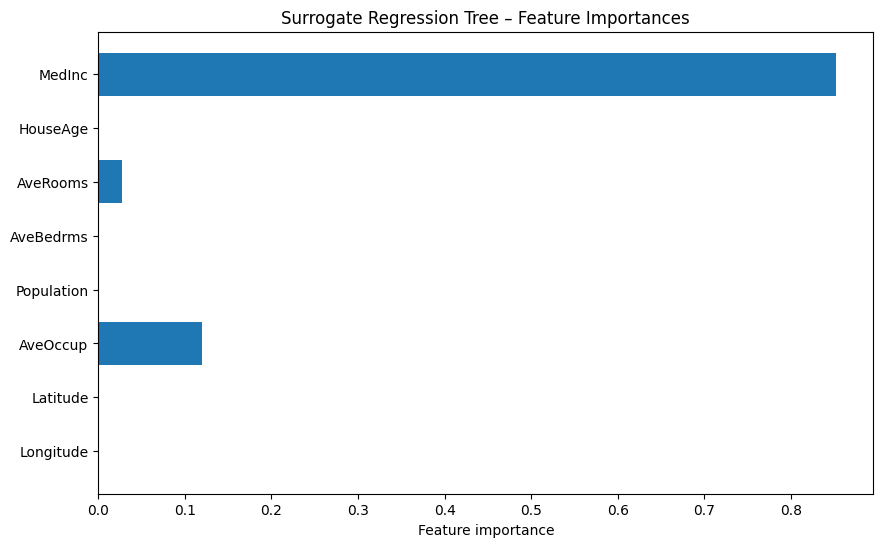

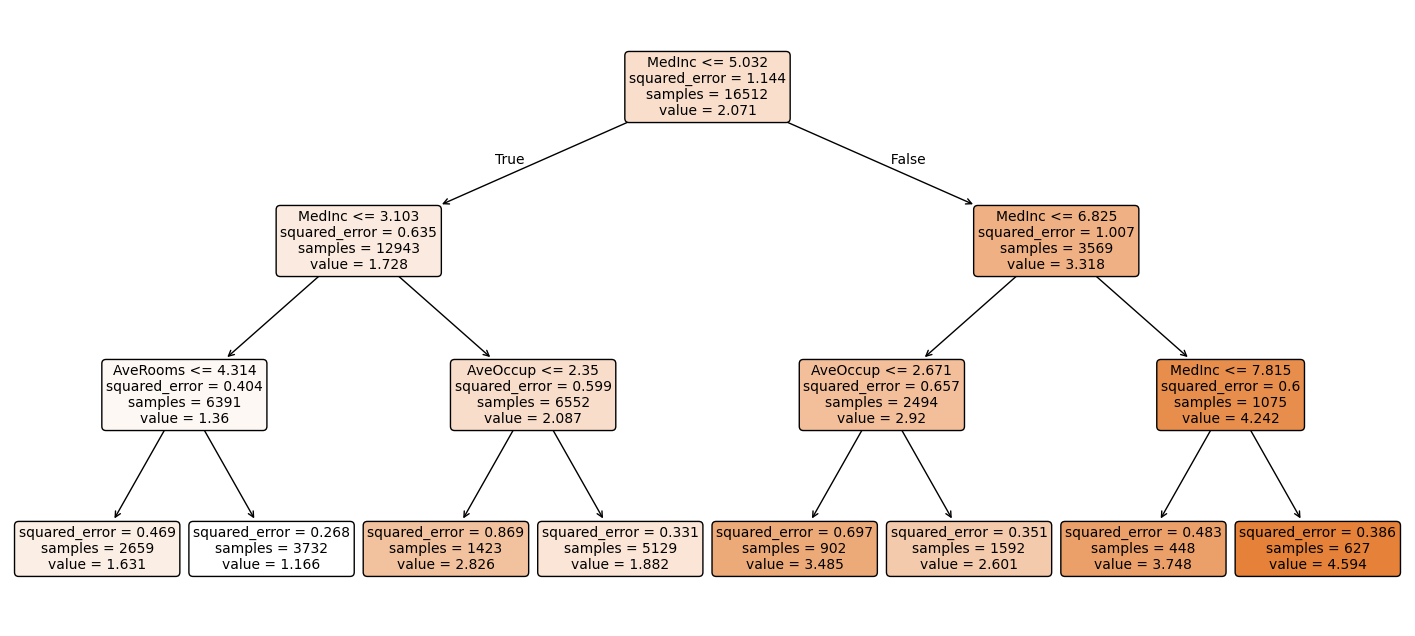

In [102]:
for name, imp in zip(X.columns, surrogate_tree.feature_importances_):
    print(f"{name}: {imp:.3f}")

plt.figure(figsize=(10,6))
plt.barh(X.columns, surrogate_tree.feature_importances_)
plt.xlabel("Feature importance")
plt.title("Surrogate Regression Tree – Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# Plot of surrogate regression tree that give the gloable explaination Here
plt.figure(figsize=(18,8))
tree.plot_tree(
    surrogate_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()



### Metrics Surrogate model on original dataset train

In [246]:
pred_true = surrogate_tree.predict(X_train)

r2_true = r2_score(target_surrogate, pred_true)
mse_true = mean_squared_error(y_train, pred_true)
rmse_true = np.sqrt(mse_true)

In [247]:
print(f"Fidelity surrogate TREE on true data:   R²={r2_true:.3f}, RMSE={rmse_true:.3f}")

Fidelity surrogate TREE on true data:   R²=0.639, RMSE=0.786


Now let train a ante-hoc regression tree directly  on original data to see the difference


In [103]:
model_direct_DTree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
model_direct_DTree.fit(X_train, y_train)

y_pred_direct_DTree = model_direct_DTree.predict(X_train)
r2_direct_DTree = r2_score(y_train, y_pred_direct_DTree)
mse_direct_DTree = mean_squared_error(y_train, y_pred_direct_DTree)
rmse_direct_DTree = np.sqrt(mse_direct_DTree)

print(f"Direct tree R² (train): {r2_direct_DTree:.3f}")
print(f"Direct tree RMSE (train): {rmse_direct_DTree:.3f}")



Direct tree R² (train): 0.538
Direct tree RMSE (train): 0.786


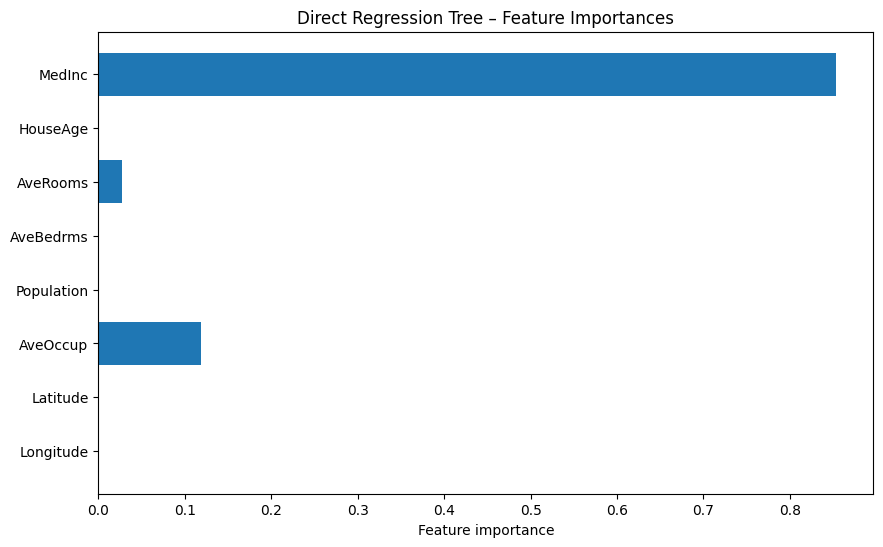

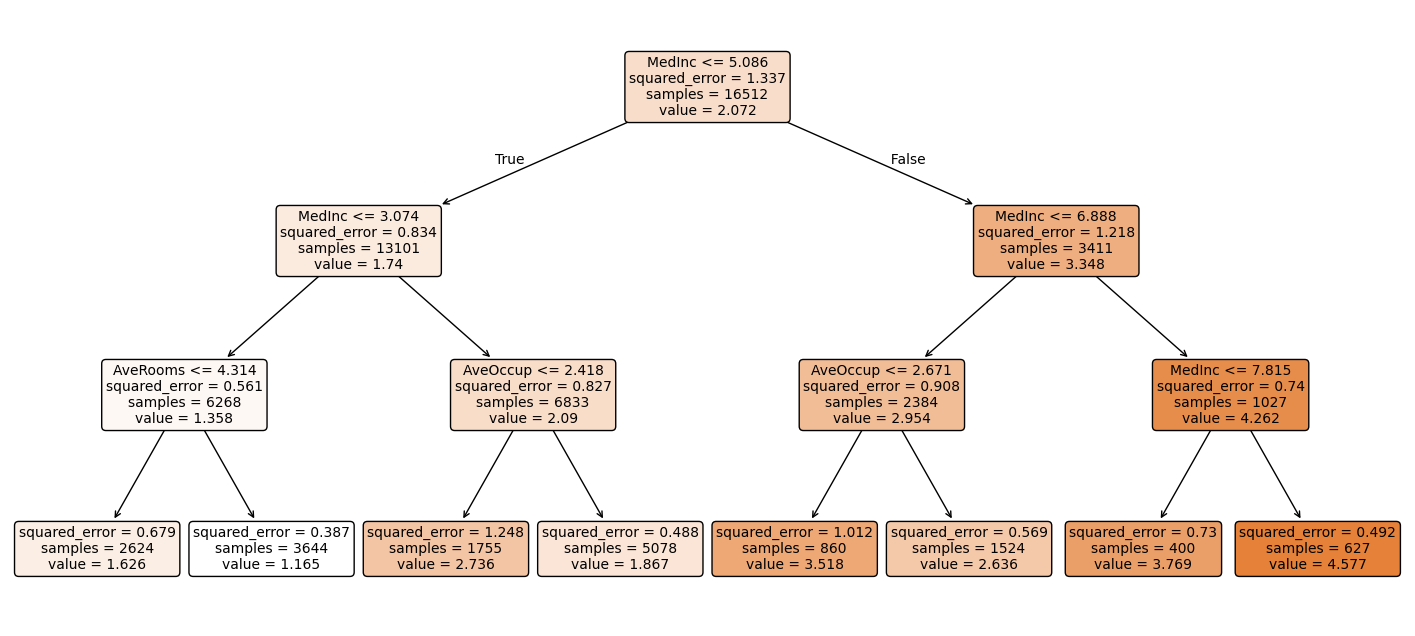

In [104]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, model_direct_DTree.feature_importances_)
plt.xlabel("Feature importance")
plt.title("Direct Regression Tree – Feature Importances")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(18,8))
tree.plot_tree(
    model_direct_DTree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

We can see that the surrogate model has almost learned the information better than a raw, naive model, and this is due to the fact that the black-box model has good performance. The R² of the surrogate is closer to 1, which shows that it explains the variance of the data very well. Thus, we have our black-box model, we train our surrogate on it, and we generate explanations based on the data predicted by the black box. We have only added this comparison on the real data to show that we gain in performance, but also that we are able to explain the predictions well.

### **Surrogate model (Linear Regressor)**

In [105]:
surrogate_linear = LinearRegression()
surrogate_linear.fit(X_train, target_surrogate)

pred_linear = surrogate_linear.predict(X_train)
r2_linear = r2_score(target_surrogate, pred_linear)
mse_linear = mean_squared_error(target_surrogate, pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"Fidelity surrogate LINEAR: R²={r2_linear:.3f}, RMSE={rmse_linear:.3f}")

Fidelity surrogate LINEAR: R²=0.719, RMSE=0.567


In [106]:
coef_df_surrogate = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": surrogate_linear.coef_,
    "AbsCoefficient": np.abs(surrogate_linear.coef_)
}).sort_values("AbsCoefficient", ascending=False)
print("Importance according to linear surrogate")
print(coef_df_surrogate)

Importance according to linear surrogate
      Feature  Coefficient  AbsCoefficient
3   AveBedrms     0.871284        0.871284
0      MedInc     0.465192        0.465192
7   Longitude    -0.406282        0.406282
6    Latitude    -0.392175        0.392175
2    AveRooms    -0.144483        0.144483
1    HouseAge     0.010374        0.010374
5    AveOccup    -0.003691        0.003691
4  Population     0.000001        0.000001


In [107]:
model_direct_LR = LinearRegression(
)
model_direct_LR.fit(X_train, y_train)

y_pred_direct_LR = model_direct_LR.predict(X_train)
r2_direct_LR = r2_score(y_train, y_pred_direct_LR)
mse_direct_LR = mean_squared_error(y_train, y_pred_direct_LR)
rmse_direct_LR = np.sqrt(mse_direct_DTree)

print(f"Linear Regressor R²  on the train: {r2_direct_LR:.3f}")
print(f"Linear Regressor  RMSE on the train: {rmse_direct_LR:.3f}")

coef_df_LR = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_direct_LR.coef_,
    "AbsCoefficient": np.abs(model_direct_LR.coef_)
}).sort_values("AbsCoefficient", ascending=False)
print("Importance according to linear surrogate")
print(coef_df_LR)

Linear Regressor R²  on the train: 0.613
Linear Regressor  RMSE on the train: 0.786
Importance according to linear surrogate
      Feature  Coefficient  AbsCoefficient
3   AveBedrms     0.783145        0.783145
0      MedInc     0.448675        0.448675
7   Longitude    -0.433708        0.433708
6    Latitude    -0.419792        0.419792
2    AveRooms    -0.123323        0.123323
1    HouseAge     0.009724        0.009724
5    AveOccup    -0.003526        0.003526
4  Population    -0.000002        0.000002


Here we can notice the rank of feature is almost the same , what the surrogate model keept and what a ante-hoc directly on original data keep.